# DeepFER: Facial Emotion Recognition Using Deep Learning
### Deep Learning for Computer Vision — Full Kaggle Pipeline

**Pipeline covered in this notebook:**
1. Setup & Configuration
2. Data Collection & Exploration (FER2013, 7 classes)
3. Data Preprocessing & Augmentation
4. Model 1 — Custom CNN (from scratch)
5. Model 2 — Transfer Learning (MobileNetV2, fine-tuned)
6. Training (with callbacks & hyperparameter tuning)
7. Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC)
8. Model Comparison
9. Performance Optimization (lightweight model, quantization, latency benchmark)
10. Export Model (.keras + .tflite) for local real-time deployment
11. Documentation Summary / Report

> **Note:** Real-time webcam inference and the Streamlit app are done **locally** (Kaggle kernels have no camera access). This notebook produces the exported trained model(s) used by the local app.


## 1. Setup & Configuration

In [20]:

import os, sys, time, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support,
                              roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Enable mixed precision if GPU available (faster training on Kaggle T4/P100)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision enabled.")
    except Exception as e:
        print("Mixed precision not enabled:", e)


TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision enabled.


In [21]:

# ---- Global Config ----
IMG_SIZE      = 48          # native FER2013 resolution (grayscale 48x48)
IMG_SIZE_TL   = 96          # upsampled resolution for transfer-learning backbone
BATCH_SIZE    = 64
EPOCHS_CNN    = 40
EPOCHS_TL     = 25
NUM_CLASSES   = 7
CLASS_NAMES   = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 2. Data Collection & Exploration

**Dataset:** FER2013 (7 emotion classes: angry, disgust, fear, happy, neutral, sad, surprise) — matches the DeepFER project spec exactly.

Add the dataset in Kaggle via **Add Input → search "FER2013" / "Face expression recognition dataset"** (msambare/fer2013 is a common public copy structured as `train/<class>/*.jpg` and `test/<class>/*.jpg`).

If your dataset copy is structured differently (single CSV with pixel strings, e.g. the original Kaggle FER2013 competition format), use the CSV-loading cell instead — both are provided below, pick whichever matches your added dataset.


In [22]:
# ---- Option A: Directory-structured dataset (train/<class>/*.jpg, test/<class>/*.jpg) ----
DATA_DIR = "/kaggle/input/datasets/msambare/fer2013"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

USE_CSV = not os.path.isdir(TRAIN_DIR)
print("Using CSV pipeline:", USE_CSV)

Using CSV pipeline: False


In [24]:

# ---- Option B: CSV-structured dataset (original FER2013: 'emotion','pixels','Usage' columns) ----
# Only runs if directory structure not found above.
if USE_CSV:
    CSV_PATH = "/kaggle/input/datasets/msambare/fer2013"   # update to your dataset's csv path
    df = pd.read_csv(CSV_PATH)
    print(df.shape)
    print(df['Usage'].value_counts())

    def csv_to_arrays(df_subset):
        pixels = df_subset['pixels'].apply(lambda x: np.array(x.split(), dtype='float32').reshape(48,48,1))
        X = np.stack(pixels.values)
        y = df_subset['emotion'].values
        return X, y

    X_train_raw, y_train_raw = csv_to_arrays(df[df['Usage']=='Training'])
    X_val_raw,   y_val_raw   = csv_to_arrays(df[df['Usage']=='PublicTest'])
    X_test_raw,  y_test_raw  = csv_to_arrays(df[df['Usage']=='PrivateTest'])
    print(X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)


### 2.1 Dataset composition / class distribution

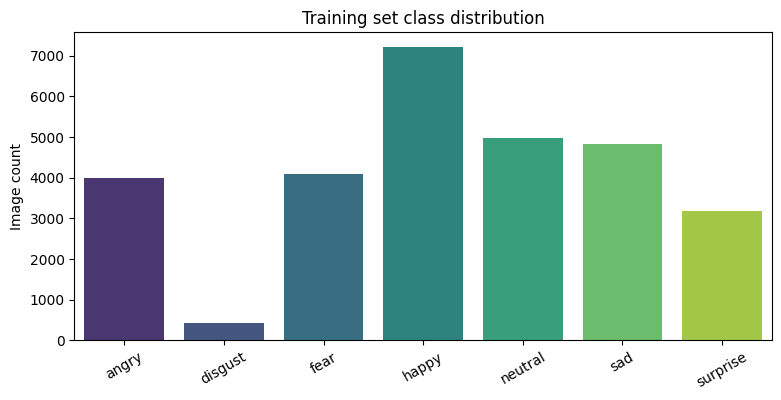

{'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}


In [25]:

if not USE_CSV:
    counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES if os.path.isdir(os.path.join(TRAIN_DIR, c))}
else:
    import collections
    counts = collections.Counter(y_train_raw)
    counts = {CLASS_NAMES[k]: v for k, v in counts.items()}

plt.figure(figsize=(9,4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
plt.title("Training set class distribution")
plt.ylabel("Image count"); plt.xticks(rotation=30)
plt.show()
print(counts)


### 2.2 Sample images per class

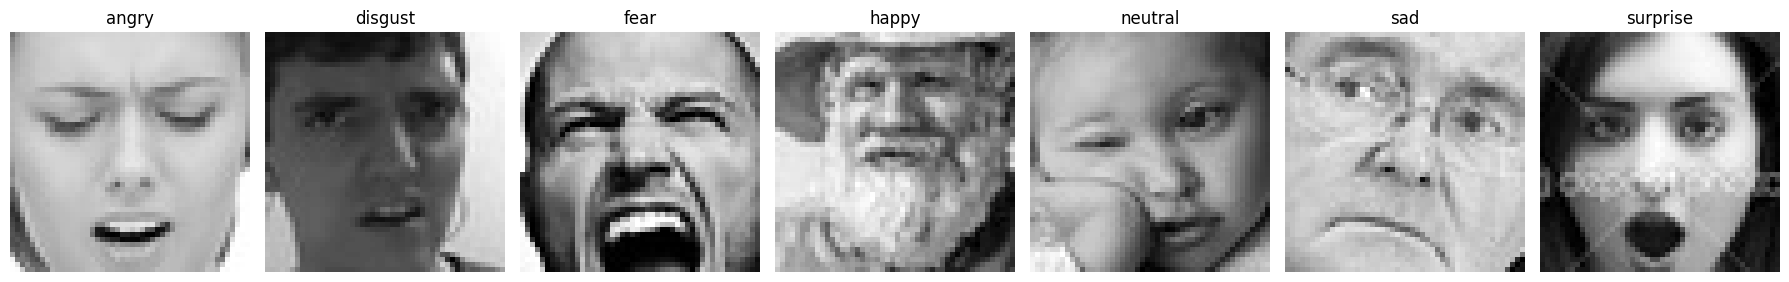

In [26]:

if not USE_CSV:
    fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18,3))
    for ax, c in zip(axes, CLASS_NAMES):
        folder = os.path.join(TRAIN_DIR, c)
        if os.path.isdir(folder):
            fname = os.listdir(folder)[0]
            img = plt.imread(os.path.join(folder, fname))
            ax.imshow(img, cmap='gray')
        ax.set_title(c); ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18,3))
    for ax, cls_idx in zip(axes, range(NUM_CLASSES)):
        idx = np.where(y_train_raw == cls_idx)[0][0]
        ax.imshow(X_train_raw[idx].squeeze(), cmap='gray')
        ax.set_title(CLASS_NAMES[cls_idx]); ax.axis('off')
    plt.tight_layout(); plt.show()


## 3. Data Preprocessing & Augmentation

- Rescale pixel values to [0,1]
- Class weighting to counter class imbalance (FER2013 is imbalanced, esp. "disgust")
- Augmentation: rotation, zoom/scaling, horizontal flip, width/height shift, brightness jitter
- Two generator pipelines: one at 48×48 (grayscale) for the from-scratch CNN, one at 96×96×3 (replicated channels) for the transfer-learning model


In [32]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    validation_split=0.1 if USE_CSV is False and os.path.isdir(TEST_DIR)==False else 0.0
)
test_datagen = ImageDataGenerator(rescale=1./255)


In [33]:

if not USE_CSV:
    train_gen_cnn = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
        class_mode='categorical', batch_size=BATCH_SIZE, classes=CLASS_NAMES,
        subset='training' if train_datagen._validation_split else None, shuffle=True, seed=SEED)

    if train_datagen._validation_split:
        val_gen_cnn = train_datagen.flow_from_directory(
            TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
            class_mode='categorical', batch_size=BATCH_SIZE, classes=CLASS_NAMES,
            subset='validation', shuffle=False)
    else:
        val_gen_cnn = None

    test_gen_cnn = test_datagen.flow_from_directory(
        TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
        class_mode='categorical', batch_size=BATCH_SIZE, classes=CLASS_NAMES, shuffle=False)

    if val_gen_cnn is None:
        val_gen_cnn = test_gen_cnn  # fallback: use test as val monitor

    # Class weights from directory counts
    y_train_labels = train_gen_cnn.classes
else:
    y_train_labels = y_train_raw


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [34]:

class_weights_arr = compute_class_weight(class_weight='balanced',
                                          classes=np.unique(y_train_labels),
                                          y=y_train_labels)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [35]:

# For CSV pipeline, build tf.data pipelines instead of flow_from_directory
if USE_CSV:
    def make_dataset(X, y, augment=False, shuffle=False, batch_size=BATCH_SIZE):
        X = X / 255.0
        y_cat = tf.keras.utils.to_categorical(y, NUM_CLASSES)
        ds = tf.data.Dataset.from_tensor_slices((X, y_cat))
        if shuffle:
            ds = ds.shuffle(4096, seed=SEED)
        ds = ds.batch(batch_size)
        if augment:
            aug_layer = tf.keras.Sequential([
                layers.RandomRotation(0.04),
                layers.RandomZoom(0.15),
                layers.RandomTranslation(0.1, 0.1),
                layers.RandomFlip("horizontal"),
            ])
            ds = ds.map(lambda x, y: (aug_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds_cnn = make_dataset(X_train_raw, y_train_raw, augment=True, shuffle=True)
    val_ds_cnn   = make_dataset(X_val_raw, y_val_raw)
    test_ds_cnn  = make_dataset(X_test_raw, y_test_raw)


## 4. Model 1 — Custom CNN (from scratch)

A CNN architecture tailored for facial emotion recognition: stacked Conv-BN-ReLU blocks with increasing filters, max pooling, dropout for regularization, and a dense classification head.


In [36]:

def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return models.Model(inputs, outputs, name="DeepFER_CustomCNN")

cnn_model = build_custom_cnn()
cnn_model.summary()


I0000 00:00:1788512355.504070      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788512355.507322      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "DeepFER_CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,216,455 (4.64 MB)

 Trainable params: 1,214,151 (4.63 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [37]:

cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


### 4.1 Callbacks & Hyperparameter tuning setup

In [38]:

cnn_ckpt_path = os.path.join(OUTPUT_DIR, "deepfer_custom_cnn_best.keras")

cnn_callbacks = [
    callbacks.ModelCheckpoint(cnn_ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]


### 4.2 Train Custom CNN

In [39]:

start = time.time()
if USE_CSV:
    history_cnn = cnn_model.fit(
        train_ds_cnn, validation_data=val_ds_cnn,
        epochs=EPOCHS_CNN, class_weight=class_weight_dict, callbacks=cnn_callbacks
    )
else:
    history_cnn = cnn_model.fit(
        train_gen_cnn, validation_data=val_gen_cnn,
        epochs=EPOCHS_CNN, class_weight=class_weight_dict, callbacks=cnn_callbacks
    )
print(f"Custom CNN training time: {(time.time()-start)/60:.1f} min")


Epoch 1/40
  1/449 ━━━━━━━━━━━━━━━━━━━━ 2:58:48 24s/step - accuracy: 0.1875 - loss: 2.0948

I0000 00:00:1788512396.840643     192 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.1617 - loss: 2.1842
Epoch 1: val_accuracy improved from None to 0.09139, saving model to /kaggle/working/deepfer_custom_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/deepfer_custom_cnn_best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 362s 754ms/step - accuracy: 0.1602 - loss: 2.1300 - val_accuracy: 0.0914 - val_loss: 1.9537 - learning_rate: 0.0010
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1662 - loss: 2.0130
Epoch 2: val_accuracy improved from 0.09139 to 0.15130, saving model to /kaggle/working/deepfer_custom_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/deepfer_custom_cnn_best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 72s 159ms/step - accuracy: 0.1763 - loss: 1.9877 - val_accuracy: 0.1513 - val_loss: 1.9131 - learning_rate: 0.0010
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.1975 - loss: 1.9037
Epoch 3: val_accuracy improved from 0.15130 to 0.27542, saving 

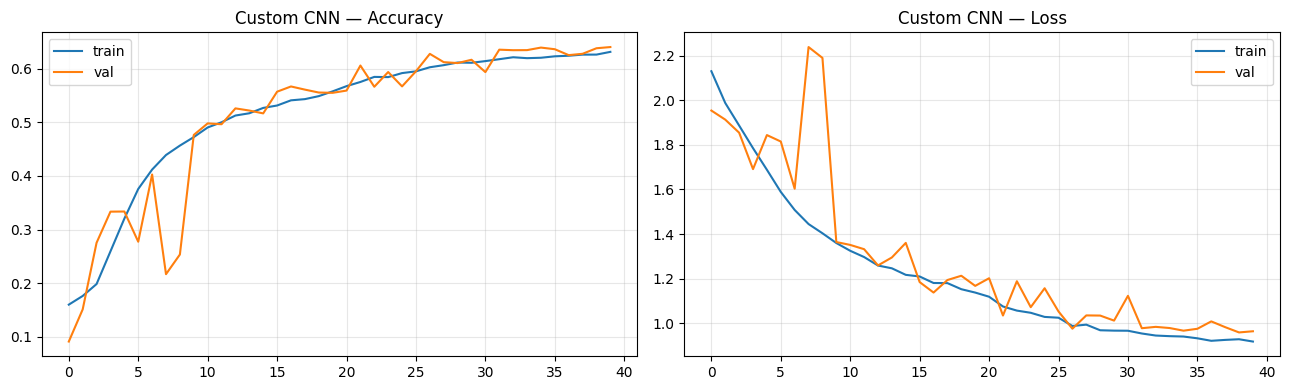

In [40]:

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title(f'{title} — Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history_cnn, "Custom CNN")


## 5. Model 2 — Transfer Learning (MobileNetV2, fine-tuned)

MobileNetV2 is chosen because it is lightweight and fast — directly supporting the **real-time / performance-optimization** requirement of the project, while Transfer Learning gives a strong accuracy baseline from ImageNet features.

Since FER2013 images are 48×48 grayscale, we upsample to 96×96 and replicate to 3 channels for the pretrained backbone.


In [41]:

def to_rgb_resize(img):
    img = tf.image.grayscale_to_rgb(img) if img.shape[-1] == 1 else img
    img = tf.image.resize(img, (IMG_SIZE_TL, IMG_SIZE_TL))
    return img

if not USE_CSV:
    def gen_to_tl_dataset(generator, augment=False):
        def gen():
            for x_batch, y_batch in generator:
                x_batch = tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_batch))
                x_batch = tf.image.resize(x_batch, (IMG_SIZE_TL, IMG_SIZE_TL))
                yield x_batch, y_batch
        ds = tf.data.Dataset.from_generator(
            gen,
            output_signature=(
                tf.TensorSpec(shape=(None, IMG_SIZE_TL, IMG_SIZE_TL, 3), dtype=tf.float32),
                tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32),
            )
        )
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds_tl = gen_to_tl_dataset(train_gen_cnn)
    val_ds_tl   = gen_to_tl_dataset(val_gen_cnn)
    test_ds_tl  = gen_to_tl_dataset(test_gen_cnn)
    steps_per_epoch_tl = len(train_gen_cnn)
    val_steps_tl = len(val_gen_cnn)
else:
    def make_tl_dataset(X, y, augment=False, shuffle=False, batch_size=BATCH_SIZE):
        X = X / 255.0
        X = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X, dtype=tf.float32))
        X = tf.image.resize(X, (IMG_SIZE_TL, IMG_SIZE_TL))
        y_cat = tf.keras.utils.to_categorical(y, NUM_CLASSES)
        ds = tf.data.Dataset.from_tensor_slices((X, y_cat))
        if shuffle:
            ds = ds.shuffle(4096, seed=SEED)
        ds = ds.batch(batch_size)
        if augment:
            aug_layer = tf.keras.Sequential([
                layers.RandomRotation(0.04), layers.RandomZoom(0.15),
                layers.RandomTranslation(0.1, 0.1), layers.RandomFlip("horizontal"),
            ])
            ds = ds.map(lambda x, y: (aug_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds_tl = make_tl_dataset(X_train_raw, y_train_raw, augment=True, shuffle=True)
    val_ds_tl   = make_tl_dataset(X_val_raw, y_val_raw)
    test_ds_tl  = make_tl_dataset(X_test_raw, y_test_raw)


In [42]:

def build_transfer_model(input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3), num_classes=NUM_CLASSES):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False  # phase 1: feature extraction

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs, name="DeepFER_MobileNetV2_TL")
    return model, base_model

tl_model, tl_base = build_transfer_model()
tl_model.compile(optimizer=optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DeepFER_MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,743 (9.88 MB)

 Trainable params: 330,247 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

### 5.1 Phase 1 — Train classification head (base frozen)

In [43]:

tl_ckpt_path = os.path.join(OUTPUT_DIR, "deepfer_mobilenetv2_best.keras")

tl_callbacks = [
    callbacks.ModelCheckpoint(tl_ckpt_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

if not USE_CSV:
    history_tl_head = tl_model.fit(
        train_ds_tl, validation_data=val_ds_tl,
        steps_per_epoch=steps_per_epoch_tl, validation_steps=val_steps_tl,
        epochs=10, class_weight=class_weight_dict, callbacks=tl_callbacks
    )
else:
    history_tl_head = tl_model.fit(
        train_ds_tl, validation_data=val_ds_tl,
        epochs=10, class_weight=class_weight_dict, callbacks=tl_callbacks
    )


Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.2835 - loss: 1.9279
Epoch 1: val_accuracy improved from None to 0.40345, saving model to /kaggle/working/deepfer_mobilenetv2_best.keras

Epoch 1: finished saving model to /kaggle/working/deepfer_mobilenetv2_best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 158s 274ms/step - accuracy: 0.3120 - loss: 1.8186 - val_accuracy: 0.4035 - val_loss: 1.5794 - learning_rate: 0.0010
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3604 - loss: 1.6485
Epoch 2: val_accuracy did not improve from 0.40345
449/449 ━━━━━━━━━━━━━━━━━━━━ 54s 120ms/step - accuracy: 0.3677 - loss: 1.6209 - val_accuracy: 0.3846 - val_loss: 1.5857 - learning_rate: 0.0010
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3812 - loss: 1.5581
Epoch 3: val_accuracy did not improve from 0.40345
449/449 ━━━━━━━━━━━━━━━━━━━━ 56s 125ms/step - accuracy: 0.3816 - loss: 1.5661 - val_accuracy: 0.3722 - val_loss: 1.6364 - learning_rate: 0.0010
Epo

### 5.2 Phase 2 — Fine-tune top layers of MobileNetV2 (unfreeze last N layers)

Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.3055 - loss: 1.8351
Epoch 1: val_accuracy did not improve from 0.44358
449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 240ms/step - accuracy: 0.3205 - loss: 1.7699 - val_accuracy: 0.3154 - val_loss: 2.0710 - learning_rate: 1.0000e-05
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3491 - loss: 1.6832
Epoch 2: val_accuracy did not improve from 0.44358
449/449 ━━━━━━━━━━━━━━━━━━━━ 56s 125ms/step - accuracy: 0.3556 - loss: 1.6395 - val_accuracy: 0.3667 - val_loss: 1.7892 - learning_rate: 1.0000e-05
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3608 - loss: 1.6413
Epoch 3: val_accuracy did not improve from 0.44358

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
449/449 ━━━━━━━━━━━━━━━━━━━━ 54s 121ms/step - accuracy: 0.3677 - loss: 1.6003 - val_accuracy: 0.3991 - val_loss: 1.6319 - learning_rate: 1.0000e-05
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accurac

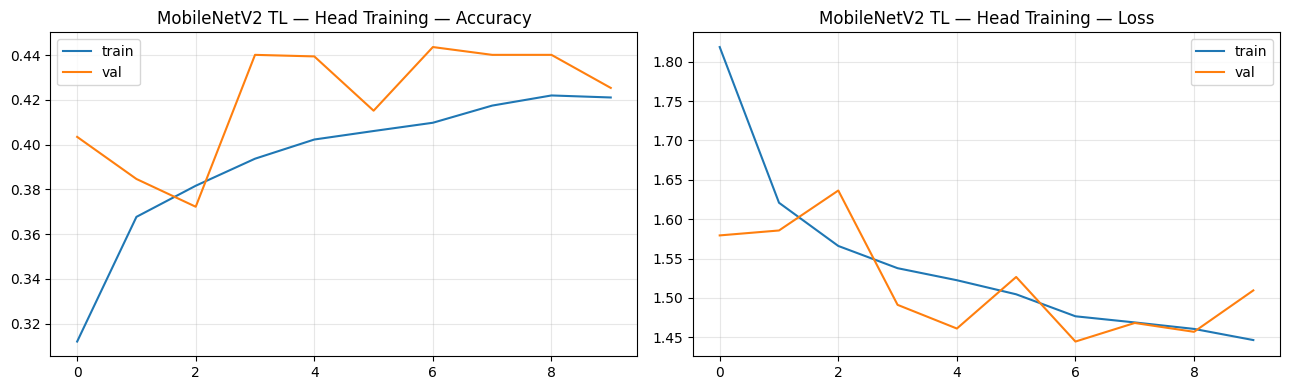

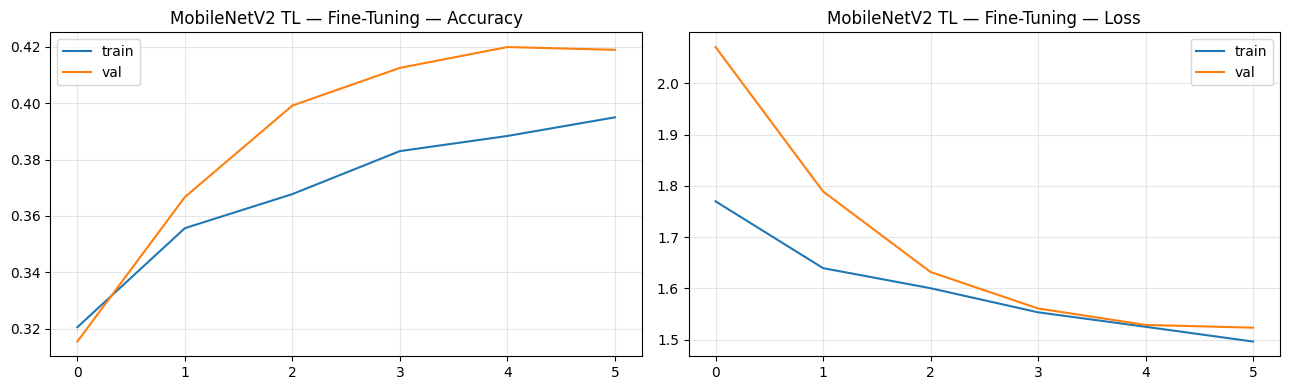

In [44]:

tl_base.trainable = True
FINE_TUNE_AT = len(tl_base.layers) - 30  # unfreeze last 30 layers only
for layer in tl_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

tl_model.compile(optimizer=optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

if not USE_CSV:
    history_tl_finetune = tl_model.fit(
        train_ds_tl, validation_data=val_ds_tl,
        steps_per_epoch=steps_per_epoch_tl, validation_steps=val_steps_tl,
        epochs=EPOCHS_TL, class_weight=class_weight_dict, callbacks=tl_callbacks
    )
else:
    history_tl_finetune = tl_model.fit(
        train_ds_tl, validation_data=val_ds_tl,
        epochs=EPOCHS_TL, class_weight=class_weight_dict, callbacks=tl_callbacks
    )

plot_history(history_tl_head, "MobileNetV2 TL — Head Training")
plot_history(history_tl_finetune, "MobileNetV2 TL — Fine-Tuning")


## 6. Evaluation — Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC

Evaluated on the held-out test set for **both** models.


In [45]:

def get_test_labels_preds(model, is_cnn=True):
    if not USE_CSV:
        gen = test_gen_cnn if is_cnn else test_ds_tl
        if is_cnn:
            y_true = gen.classes
            preds = model.predict(gen, verbose=1)
        else:
            y_true = test_gen_cnn.classes
            preds = model.predict(gen, steps=len(test_gen_cnn), verbose=1)
    else:
        ds = test_ds_cnn if is_cnn else test_ds_tl
        y_true = y_test_raw
        preds = model.predict(ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    return y_true, y_pred, preds

y_true_cnn, y_pred_cnn, probs_cnn = get_test_labels_preds(cnn_model, is_cnn=True)
y_true_tl,  y_pred_tl,  probs_tl  = get_test_labels_preds(tl_model, is_cnn=False)


113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 200ms/step


In [54]:
# Fresh, independent generator for MobileNetV2 TL evaluation (avoids shared-state bug)
tl_test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
    class_mode='categorical', batch_size=BATCH_SIZE, classes=CLASS_NAMES, shuffle=False
)

def tl_eval_dataset(generator):
    def gen():
        generator.reset()
        for x_batch, y_batch in generator:
            x_batch = tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_batch))
            x_batch = tf.image.resize(x_batch, (IMG_SIZE_TL, IMG_SIZE_TL))
            yield x_batch, y_batch
    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(None, IMG_SIZE_TL, IMG_SIZE_TL, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32),
        )
    ).prefetch(tf.data.AUTOTUNE)

y_true_tl = tl_test_gen.classes
probs_tl = tl_model.predict(tl_eval_dataset(tl_test_gen), steps=len(tl_test_gen), verbose=1)
y_pred_tl = np.argmax(probs_tl, axis=1)

Found 7178 images belonging to 7 classes.
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step


In [55]:

def full_report(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f"===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    return {"model": model_name, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

metrics_cnn = full_report(y_true_cnn, y_pred_cnn, "Custom CNN")
metrics_tl  = full_report(y_true_tl, y_pred_tl, "MobileNetV2 Transfer Learning")


===== Custom CNN =====
Accuracy : 0.6378
Precision: 0.6438
Recall   : 0.6378
F1-score : 0.6309

              precision    recall  f1-score   support

       angry       0.55      0.59      0.57       958
     disgust       0.54      0.66      0.60       111
        fear       0.49      0.37      0.42      1024
       happy       0.89      0.82      0.86      1774
     neutral       0.52      0.75      0.61      1233
         sad       0.59      0.39      0.47      1247
    surprise       0.69      0.85      0.76       831

    accuracy                           0.64      7178
   macro avg       0.61      0.63      0.61      7178
weighted avg       0.64      0.64      0.63      7178

===== MobileNetV2 Transfer Learning =====
Accuracy : 0.3154
Precision: 0.4866
Recall   : 0.3154
F1-score : 0.3201

              precision    recall  f1-score   support

       angry       0.40      0.08      0.13       958
     disgust       0.03      0.89      0.07       111
        fear       0.39      

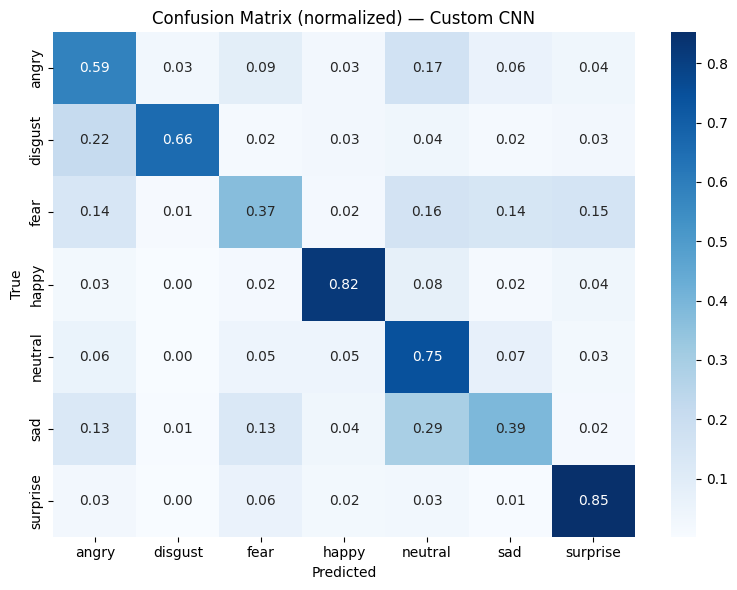

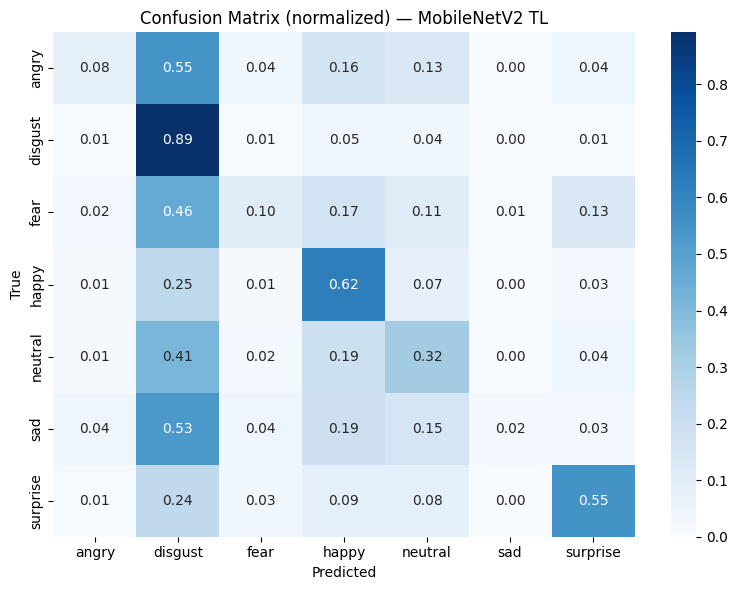

In [56]:

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix (normalized) — {title}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

plot_confusion(y_true_cnn, y_pred_cnn, "Custom CNN")
plot_confusion(y_true_tl, y_pred_tl, "MobileNetV2 TL")


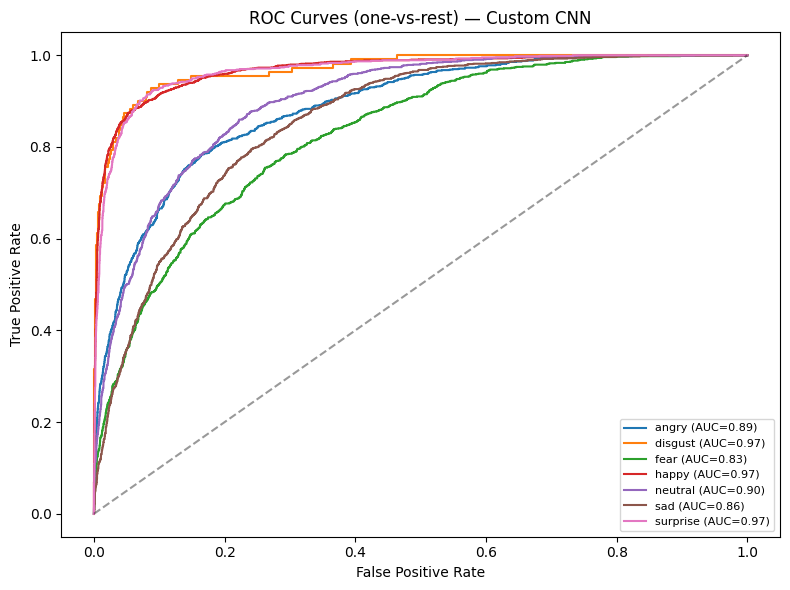

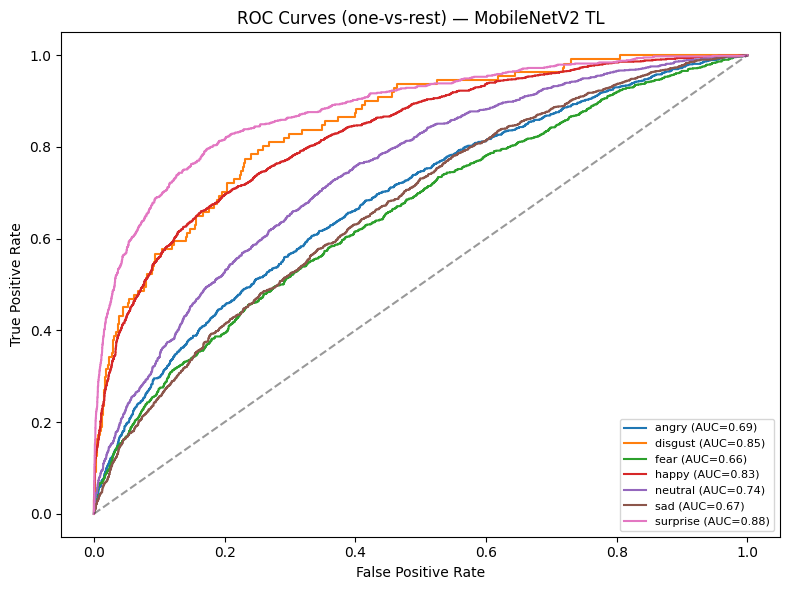

In [57]:

def plot_roc(y_true, probs, title):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    plt.figure(figsize=(8,6))
    for i, cname in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],'k--', alpha=0.4)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves (one-vs-rest) — {title}')
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()

plot_roc(y_true_cnn, probs_cnn, "Custom CNN")
plot_roc(y_true_tl, probs_tl, "MobileNetV2 TL")


## 7. Model Comparison

In [58]:

comparison_df = pd.DataFrame([metrics_cnn, metrics_tl])
comparison_df


,model,accuracy,precision,recall,f1
0,Custom CNN,0.637782,0.643764,0.637782,0.630861
1,MobileNetV2 Transfer Learning,0.315408,0.486596,0.315408,0.320115


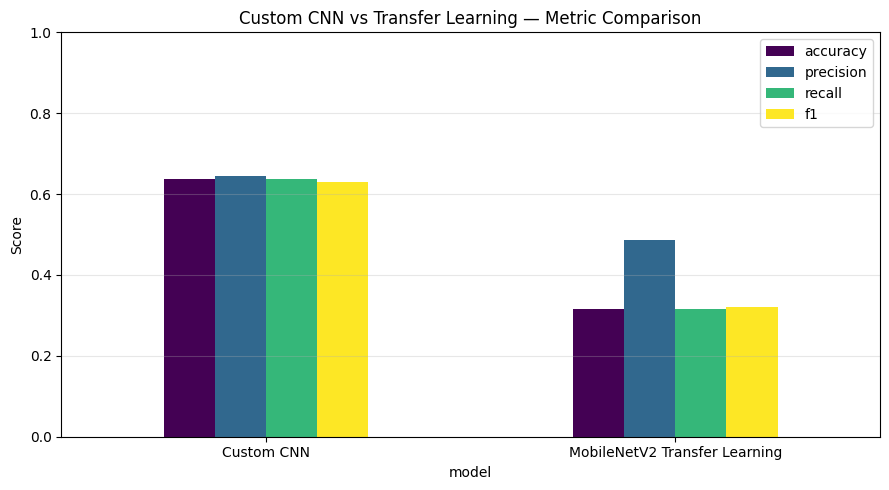

In [59]:

comparison_df.set_index('model')[['accuracy','precision','recall','f1']].plot(
    kind='bar', figsize=(9,5), rot=0, colormap='viridis'
)
plt.title("Custom CNN vs Transfer Learning — Metric Comparison")
plt.ylabel("Score"); plt.ylim(0,1); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Performance Optimization (for Real-Time Deployment)

Benchmark inference latency of both models, then produce a quantized **TFLite** version of the best/lightest model — this is what makes real-time webcam inference feasible locally.


In [60]:

def benchmark_latency(model, input_shape, n_runs=100):
    dummy = np.random.rand(1, *input_shape).astype('float32')
    # warmup
    for _ in range(10):
        model.predict(dummy, verbose=0)
    start = time.time()
    for _ in range(n_runs):
        model.predict(dummy, verbose=0)
    avg_ms = (time.time() - start) / n_runs * 1000
    return avg_ms

cnn_latency = benchmark_latency(cnn_model, (IMG_SIZE, IMG_SIZE, 1))
tl_latency  = benchmark_latency(tl_model, (IMG_SIZE_TL, IMG_SIZE_TL, 3))

print(f"Custom CNN avg inference latency : {cnn_latency:.2f} ms/frame  (~{1000/cnn_latency:.1f} FPS)")
print(f"MobileNetV2 TL avg inference latency: {tl_latency:.2f} ms/frame  (~{1000/tl_latency:.1f} FPS)")


Custom CNN avg inference latency : 83.29 ms/frame  (~12.0 FPS)
MobileNetV2 TL avg inference latency: 87.99 ms/frame  (~11.4 FPS)


In [61]:

# Pick the best-accuracy model as the deployment candidate, but export BOTH for flexibility.
best_model_name = "Custom CNN" if metrics_cnn['f1'] >= metrics_tl['f1'] else "MobileNetV2 Transfer Learning"
best_model = cnn_model if best_model_name == "Custom CNN" else tl_model
print("Best model by F1-score:", best_model_name)


Best model by F1-score: Custom CNN


In [62]:
from tensorflow.keras import mixed_precision

# Temporarily force float32 so TFLite conversion works cleanly
mixed_precision.set_global_policy('float32')

export_model = build_custom_cnn()
export_model.set_weights(best_model.get_weights())

tflite_path = os.path.join(OUTPUT_DIR, "deepfer_deploy_model.tflite")
convert_to_tflite(export_model, tflite_path, quantize=True)

mixed_precision.set_global_policy('mixed_float16')

INFO:tensorflow:Assets written to: /tmp/tmpr1dzpq_b/assets


INFO:tensorflow:Assets written to: /tmp/tmpr1dzpq_b/assets


Saved artifact at '/tmp/tmpr1dzpq_b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='keras_tensor_204')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  138325162242896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162245200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162245776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162241552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162231376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162243664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162243088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162244240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162244624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162241936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138325162245

W0000 00:00:1788516741.482594      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788516741.482625      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


## 9. Export Models & Artifacts (download these from Kaggle "Output" for local use)

- `deepfer_custom_cnn_best.keras` — full custom CNN
- `deepfer_mobilenetv2_best.keras` — full transfer-learning model
- `deepfer_deploy_model.tflite` — quantized, deployment-ready model for the local real-time app
- `class_names.json` — label mapping needed at inference time
- `model_comparison.csv` — metrics summary for the report


In [66]:

with open(os.path.join(OUTPUT_DIR, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f)

comparison_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)

# Also save full models explicitly (in case ModelCheckpoint didn't trigger due to short runs)
cnn_model.save(os.path.join(OUTPUT_DIR, "deepfer_custom_cnn_final.keras"))
tl_model.save(os.path.join(OUTPUT_DIR, "deepfer_mobilenetv2_final.keras"))

print("All artifacts saved to:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))


All artifacts saved to: /kaggle/working
['model_comparison.csv', '.gradio', 'class_names.json', 'deepfer_mobilenetv2_best.keras', 'deepfer_custom_cnn_final.keras', 'deepfer_deploy_model.tflite', 'deepfer_custom_cnn_best.keras', '.virtual_documents', 'deepfer_mobilenetv2_final.keras']


In [63]:
!pip install gradio -q

In [65]:
def predict_emotion(image):
    if image is None:
        return None, "Please upload an image."

    img_rgb = np.array(image.convert('RGB'))
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(48, 48))

    if len(faces) == 0:
        face_crop = img_gray
        img_display = img_rgb.copy()
    else:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        face_crop = img_gray[y:y+h, x:x+w]
        img_display = img_rgb.copy()
        cv2.rectangle(img_display, (x, y), (x+w, y+h), (0, 255, 0), 3)

    face_resized = cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))
    face_norm = face_resized.astype('float32') / 255.0
    face_input = face_norm.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    preds = cnn_model.predict(face_input, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_class = CLASS_NAMES[pred_idx]
    confidence = preds[pred_idx] * 100

    # Bigger, cleaner Markdown output instead of a cramped textbox
    result_md = f"## 🎯 Predicted Emotion: **{pred_class.upper()}**\n"
    result_md += f"### Confidence: {confidence:.1f}%\n\n"
    result_md += "---\n\n### Full breakdown:\n\n"
    for cname, p in sorted(zip(CLASS_NAMES, preds), key=lambda x: -x[1]):
        bar = "█" * int(p * 30)
        result_md += f"**{cname:10s}** `{p*100:5.2f}%`  {bar}\n\n"

    return Image.fromarray(img_display), result_md

demo = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Image(type="pil", label="Upload a face photo", height=350),
    outputs=[
        gr.Image(type="pil", label="Detected Face", height=350),
        gr.Markdown(label="Prediction Result")
    ],
    title="DeepFER — Facial Emotion Recognition",
    description="Upload a photo with a visible face to detect the emotion (angry, disgust, fear, happy, neutral, sad, surprise).",
    flagging_mode="never"
)

demo.launch(share=True, debug=False)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://1c93021d635f8ff088.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

## 10. Documentation & Summary Report

**Objective recap:** Build DeepFER — a CNN + Transfer-Learning based system to classify facial expressions into 7 emotions (angry, disgust, fear, happy, neutral, sad, surprise) accurately and efficiently enough for real-time use.

**What was done in this notebook:**
- Loaded and explored the FER2013 dataset (class distribution, sample visualization).
- Preprocessed and augmented data (rotation, zoom, shift, flip, brightness) with class-weighting to handle imbalance.
- Built and trained a **custom CNN from scratch** (Conv-BN-ReLU blocks, dropout, GAP head).
- Built and fine-tuned a **Transfer Learning model** (MobileNetV2, 2-phase: frozen head → fine-tune top layers).
- Evaluated both models with accuracy, precision, recall, F1-score, confusion matrices, and ROC/AUC curves.
- Compared both models side by side.
- Benchmarked inference latency and exported a **quantized TFLite model** for fast, real-time-ready inference.
- Exported all trained models + metadata for the local deployment stage.

**Next steps (done locally, outside Kaggle — no camera access here):**
1. Load `deepfer_deploy_model.tflite` (or the `.keras` model) in a local Python environment.
2. Use OpenCV / MediaPipe for face detection on webcam frames.
3. Crop, resize, normalize each detected face and run inference for the emotion label.
4. Wrap it in a Streamlit app (live video feed + predicted emotion overlay) for the "Application Development" and "Deployment & Testing" objectives.

**Findings / Challenges to note in your final report:**
- Class imbalance (esp. "disgust", the smallest class in FER2013) — addressed via class weights; still typically the hardest class (check its row in the confusion matrix).
- Low native resolution (48×48) limits fine detail — augmentation and BatchNorm help generalization.
- Transfer learning generally converges faster and can generalize better with limited fine-tuning epochs, but the lightweight custom CNN may have lower latency — compare using the metrics/latency numbers printed above for your specific run.
